In [ ]:
%matplotlib inline

# DIY `torch.nn`, `torch.optim`, and `DataLoader`

PyTorch provides the elegantly designed modules and classes
[torch.nn](https://pytorch.org/docs/stable/nn.html) ,
[torch.optim](https://pytorch.org/docs/stable/optim.html) ,
[Dataset](https://pytorch.org/docs/stable/data.html?highlight=dataset#torch.utils.data.Dataset)
, and
[DataLoader](https://pytorch.org/docs/stable/data.html?highlight=dataloader#torch.utils.data.DataLoader)
to help you create and train neural networks. 

To fully utilize their power and adjust them to your needs, you should realy understand them.

We will be following the [Tutorial by Jeremy Howard](https://docs.pytorch.org/tutorials/beginner/nn_tutorial.html).

1. Train basic neural network on MNIST dataset only using PyTorch tensor functionality
2. Incrementally add features from `torch.nn`, `torch.optim`, `Dataset`, or `DataLoader`

# MNIST data setup

[MNIST](https://yann.lecun.com/exdb/mnist/index.html) dataset consists of black-and-white images of hand-drawn digits (0 to 9).



In [ ]:
from pathlib import Path # for path handling, part of Python3 standard library
import requests # simple and elegant 3rd party library

data_path = Path("data")

data_path.mkdir(parents=True, exist_ok=True)

filename = "mnist.pkl.gz"

if not (data_path / filename).exists():
    content = requests.get("https://github.com/pytorch/tutorials/raw/main/_static/" + filename).content
    (data_path / filename).open("wb").write(content)

This dataset is in numpy array format, and has been stored using pickle.

In [ ]:
import pickle
import gzip

with gzip.open((data_path / filename).as_posix(), "rb") as f:
    ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")
print("shape:", x_train.shape)

Each image is 28 x 28, and is being stored as a flattened row of length
784 (=28x28). Let\'s take a look at one; we need to reshape it to 2d
first.


In [ ]:
from matplotlib import pyplot
import numpy as np

pyplot.imshow(x_train[0].reshape((28, 28)), cmap="gray")
pyplot.show()
print(f"{y_train[0]=}")

PyTorch uses `torch.tensor` as base data type, rather than numpy arrays.


In [ ]:
import torch

x_train = torch.tensor(x_train)
y_train = torch.tensor(y_train)
x_valid = torch.tensor(x_valid)
y_valid = torch.tensor(y_valid)

n, c = x_train.shape
print(x_train, y_train)
print("x_train.shape:", x_train.shape)
print("y_train.min():", y_train.min(), "y_train.max():", y_train.max())

# Neural net from scratch (without `torch.nn`)

We create the first model just from Pytorch tensors. We will use one
speacial ability that is the **automatic computation of gradients** of model parameters.
In the back propagation will then use the model derivertives with respect to the parameters
as part of the model training.

In [ ]:
bias = torch.zeros(10, requires_grad=True)
weights = torch.randn(784, 10)
weights.requires_grad_() # start gradient computation after initialisation of values
# Methods ending with underscore modify tensors in-place

You can chain computations and the gradients will be computed automatically using the chain-rule.

Internally, all computation steps are recorded in a directed acyclic graph (DAG).

Let\'s define our own log_softmax:
$$
\sigma(\mathbf{x})_i = \log( \frac{e^{x_i}}{\sum_{j=1}^K e^{x_j}} ) = x_i - \log( {\sum_{j=1}^K e^{x_j}} ) 
$$

and linear model:

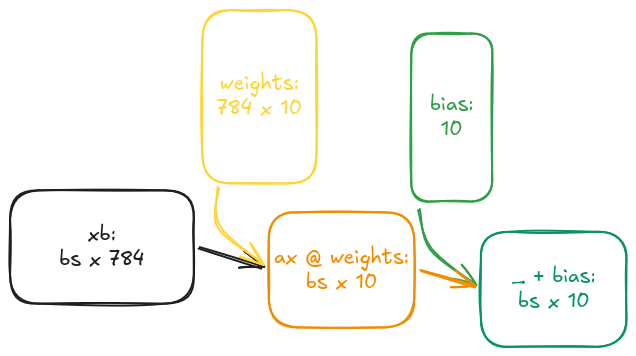

In [ ]:
def log_softmax(x): # would later be captured by torch.nn.functional.cross_entropy
    return x - x.exp().sum(-1).log().unsqueeze(-1)

def model(xb): # would become a class derived from torch.nn.Module
    return log_softmax(xb @ weights + bias) # with `@` being matrix multiplication

We will call our function on one batch of data (in this case, 64 images).
This is one *forward pass*. Note that our predictions won\'t be any
better than random at this stage, since we start with random weights.


In [ ]:
bs = 64  # batch size

xb = x_train[0:bs]  # a batch from x
preds = model(xb)  # predictions
print(preds[0])
print("preds.shape:", preds.shape)

Note, that the `preds` tensor contains not only the tensor values, but
also a gradient function. We\'ll use this later to do back propagation.

Let\'s implement negative log-likelihood to use as the loss function

In [ ]:
def negative_log_likelihood(input, target): # would later be captured by torch.nn.functional.cross_entropy
    # we want to maximize the input value at the position of target.
    return -input[range(target.shape[0]), target].mean()

loss_func = negative_log_likelihood

Let\'s check our loss with our random model, so we can see if we improve
after a backprop pass later.


In [ ]:
yb = y_train[0:bs]
print(loss_func(preds, yb))

Let\'s also implement a function to calculate the accuracy of our model.
For each prediction, if the index with the largest value matches the
target value, then the prediction was correct.


In [ ]:
def accuracy(out, yb):
    preds = torch.argmax(out, dim=1)
    return (preds == yb).float().mean()

Let\'s check the accuracy of our random model, so we can see if our
accuracy improves as our loss improves.


In [ ]:
print(accuracy(preds, yb))

## Training loop
We can now run a training loop. For each iteration, we will:

-   select a batch of data (of size `bs`)
-   use the model to make predictions
-   calculate the loss
-   `loss.backward()` updates the gradients of the model, in this case,
    `weights` and `bias`.

Calling `loss.backward()` fills `bias.grad` and `weights.grad`.

Correct `bias` and `weights` within the `torch.no_grad()` context manager, 
to not have these action recorded for next calculation of the gradient.

In [ ]:
from IPython.core.debugger import set_trace

lr = 0.15  # learning rate
epochs = 5  # how many epochs to train for
loss_step = []
accuracy_step = []

for epoch in range(epochs):
    for i in range((n - 1) // bs + 1):
        # set_trace() # normal Python debugger could be used here.
        start_i = i * bs
        end_i = start_i + bs
        # Pairs of x_train, y_train would later be provided by torch.utils.data.TensorDataset 
        # And torch.utils.data.DataLoader would provide batches.
        xb = x_train[start_i:end_i]
        yb = y_train[start_i:end_i]
        pred = model(xb)
        loss = loss_func(pred, yb)

        loss.backward()
        with torch.no_grad():
            # this look body would be covered by torch.nn.Module
            # before being replaced by torch.optim.SGD()
            weights -= weights.grad * lr
            bias -= bias.grad * lr
            weights.grad.zero_()
            bias.grad.zero_()

            loss_step.append(loss.detach().numpy())
            accuracy_step.append(accuracy(model(xb), yb).detach().numpy())

pyplot.plot(loss_step); pyplot.show()
pyplot.plot(accuracy_step); pyplot.show()


That\'s it: we\'ve created and trained a minimal neural network (in this
case, a logistic regression, since we have no hidden layers) entirely
from scratch!

Let\'s check the loss and accuracy and compare those to what we got
earlier. We expect that the loss will have decreased and accuracy to
have increased, and they have.


In [ ]:
print(loss_func(model(xb), yb), accuracy(model(xb), yb))

Using the validation data

In [ ]:
print(loss_func(model(x_valid), y_valid), accuracy(model(x_valid), y_valid))

Inference on test cases:

In [ ]:
pyplot.imshow(x_valid[0].reshape((28, 28)), cmap="gray")
pyplot.show()

print("Model:", torch.argmax(model(x_valid[0]), dim=-1))

# Exercise

Log loss and accuracy during training and visualize them

---

To continue refactoring the example using `torch.nn`, `torch.optim`, and `DataLoader` follow 
https://docs.pytorch.org/tutorials/beginner/nn_tutorial.html

Or learn more about the computational graph and autograd: https://docs.pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html